# Supervised Learning — Metrics for Classification

In this notebook, we'll look at the most common ways to evaluate classification models. 

>
> ℹ️ Info about this notebook:
>
> - Goal: learn the most common classification metrics.
> - Dataset: Titanic Dataset
> - Model: Logistic Regression
> - Metrics: Confusion Matrix, Accuracy, Precision, Recall, F1-Score
> 


<br>

---

<br>

## Initial Setup

We'll use the **Titanic dataset** — a classic classification problem.  
The goal: **predict whether a passenger survived** (1) or not (0).

### Features we'll use
| Feature | Description |
|---|---|
| `pclass` | Passenger class (1, 2, 3) |
| `sex` | Gender (encoded as 0/1) |
| `age` | Age in years |
| `fare` | Ticket fare |

We'll keep preprocessing minimal — the focus here is on the metrics, not feature engineering.

In [1]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
df = sns.load_dataset("titanic")

# Minimal cleaning
df = df[["survived", "pclass", "sex", "age", "fare"]].dropna()
df["sex"] = df["sex"].map({"male": 0, "female": 1})

df.head()

,survived,pclass,sex,age,fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [2]:
# Define features and target
X = df[["pclass", "sex", "age", "fare"]]
y = df["survived"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)                  # class labels (0 or 1)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"\nFirst 10 predictions : {y_pred[:10]}")
print(f"Actual labels        : {y_test.values[:10]}")


Training samples : 571
Test samples     : 143

First 10 predictions : [0 1 1 1 0 0 1 1 1 1]
Actual labels        : [0 1 1 1 0 1 1 1 0 0]


<br>

---

<br>

## 1. Confusion Matrix

The **confusion matrix** is the foundation of all classification metrics. It shows us a breakdown of what the model got right and wrong:

|  | Predicted: 0 | Predicted: 1 |
|--|-------------|-------------|
| **Actual: 0** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual: 1** | False Negative (FN) ❌ | True Positive (TP) ✅ |

- **TN** — correctly predicted "did not survive"
- **TP** — correctly predicted "survived"
- **FP** — predicted "survived" but they didn't ❌
- **FN** — predicted "did not survive" but they did ❌


<br>

![meme-confusion-matrix](../_images/meme-confusion-matrix.jpeg)

<br>

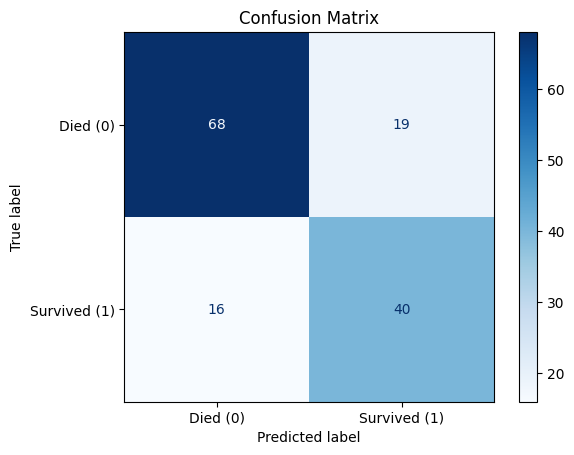

TN=68  FP=19
FN=16  TP=40


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died (0)", "Survived (1)"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

print(f"TN={cm[0,0]}  FP={cm[0,1]}")
print(f"FN={cm[1,0]}  TP={cm[1,1]}")

<br>

---

<br>

## 2. Accuracy

**Accuracy** is the most intuitive metric: out of all predictions, how many were correct?


$$\text{Accuracy} = \frac{\text{Correct predictions}}{\text{Total predictions}}$$

<br>

Or, more specifically:


$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

<br>

### ⚠️ Limitation: class imbalance

Accuracy is simple and intuitive, but it can be misleading, specially with imbalanced datasets.

For example, imagine a dataset where 95% of passengers died. A model that **always predicts "died"** would get 95% accuracy — but it never identifies any survivors!  
This is why accuracy alone is not enough.

In [5]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7552


<br><hr><hr><br>

## Research: Precision vs. Recall

- What they are + when you may want to prioritize each of them

Time: 12 minutes.

<br><hr><hr><br>


## 3. Precision

**Precision** measures how many of the items your model predicted as positive were actually positive.

In this example, precision answers the question: *"Of all the passengers we predicted would survive, how many actually did?"*

$$\text{Precision} = \frac{TP}{TP + FP}$$

![precission-recall](../_images/precission-recall.png)

(Image source: [Medium](https://medium.com/@weidagang/demystifying-precision-and-recall-in-machine-learning-6f756a4c54ac))

<br>

**Range:** Precision ranges from **0 to 1** (or 0% to 100%).
- **1.0 (100%)** → Perfect precision: every passenger we predicted as a survivor actually survived — no false alarms.
- **0.0 (0%)** → Worst precision: every positive prediction was wrong — the model only generates false alarms.
- A value of **0.75** means 75% of the passengers predicted to survive actually did survive.

**How to Interpret Precision:**
- High precision → few false alarms (when we say "survived", we're usually right)
- Low precision → we're over-predicting survivors

**When to prioritize precision?**
- When false positives are costly.  
- Example: spam detection — you don't want to wrongly mark real emails as spam.

In [6]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

Precision: 0.6780


<br>

---

<br>

## 4. Recall (Sensitivity)

Recall measures how many of the actual positive cases your model successfully identified.

In this example, recall answers the question: *"Of all the passengers who actually survived, how many did we correctly identify?"*

$$\text{Recall} = \frac{TP}{TP + FN}$$

**Range:** Recall ranges from **0 to 1** (or 0% to 100%).
- **1.0 (100%)** → Perfect recall: every passenger who actually survived was correctly identified — no survivors were missed.
- **0.0 (0%)** → Worst recall: the model failed to identify any actual survivors — all positives were missed.
- A value of **0.75** means 75% of the passengers who actually survived were correctly predicted as survivors.


**How to interpret Recall:**
- High recall → we catch most of the true positives (few missed survivors)
- Low recall → we're missing a lot of actual positives

**When to prioritize recall?**
- When false negatives are costly.  
- Example: cancer diagnosis — you really don't want to miss a sick patient.

In [7]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

Recall: 0.7143


<br>

### Precision vs Recall tradeoff
There's an inherent tradeoff: if you want to catch more positives (higher recall), you'll likely accept more false alarms (lower precision), and vice versa.

<br>

---

<br>

## 5. F1-Score

The **F1-score** combines precision and recall into a single number using their **harmonic mean**:

$$\text{F1} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

- It ranges from 0 (worst) to 1 (best)
- It penalizes models that are good at one but terrible at the other
- **Use F1 when you need a balance between precision and recall**, especially with imbalanced classes



Note: The F1 score depends on which class is considered the positive class because precision and recall are computed relative to that class (so, for example, in binary classification, there are two different F1 scores, one for each class).

<br>

---

<br>

## 6. `classification_report`
sklearn's `classification_report` gives you precision, recall, and F1 in one table — very handy!

In [10]:
from sklearn.metrics import f1_score, classification_report

f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=["Died", "Survived"]))

F1-Score: 0.6957

Full classification report:
              precision    recall  f1-score   support

        Died       0.81      0.78      0.80        87
    Survived       0.68      0.71      0.70        56

    accuracy                           0.76       143
   macro avg       0.74      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



<br>

---

<br>

## 7. ROC Curve & AUC

All the metrics above are based on a **fixed threshold** (by default, 0.5): if the predicted probability is ≥ 0.5, we predict class 1.

But what if we change that threshold? The **ROC Curve** visualizes how the model performs across **all possible thresholds**.

### Key terms
- **TPR (True Positive Rate)** = Recall = $\frac{TP}{TP + FN}$
- **FPR (False Positive Rate)** = $\frac{FP}{FP + TN}$ — how often we falsely alarm

The ROC curve plots TPR vs FPR as the threshold varies from 0 to 1.

### AUC — Area Under the Curve
- **AUC = 1.0** → perfect model
- **AUC = 0.5** → random guessing (diagonal line)
- **AUC > 0.8** → generally considered good

> AUC is especially useful for **comparing models** independent of any specific threshold.

<br>

![metrics-roc](../_images/metrics-roc.png)

(Image source: [Medium](https://medium.com/@msong507/understanding-the-roc-auc-curve-cc204f0b3441))

<br>


In [21]:
# We can actually see the probabilities estimated by the model (ie. how confident is the model in each prediction):
# `predict_proba()` returns a probability (0-1) for each class.

print(f"\nFirst 10 predictions made by the model... \n{y_pred[:10]}")

y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of class 1 (survived)
print(f"\nProbabilities for the first 10 predictions... \n{y_pred_proba[:10]}")



First 10 predictions made by the model... 
[0 1 1 1 0 0 1 1 1 1]

Probabilities for the first 10 predictions... 
[0.16103565 0.50179645 0.80768416 0.94774392 0.05044105 0.44989805
 0.50553645 0.592073   0.5579138  0.60946593]


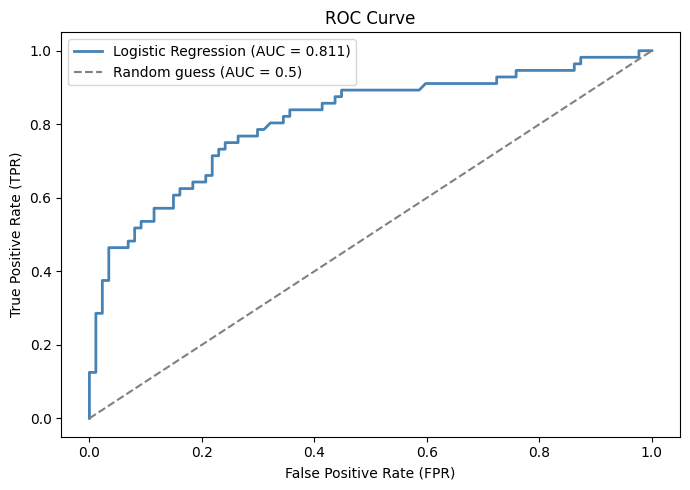

AUC: 0.8110


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", color="steelblue", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

<br>

---

<br>

## 8. Constraints and other metrics

In many ML projects, it is common to **combine metrics** or use **metric variations** depending on the business problem.


<br>

### 9.1 Metric constraints

Instead of optimizing a single metric, you can set a **minimum threshold** on one metric while maximizing another.

**Example — spam filter:**
> *"Maximize precision, subject to recall ≥ 0.60"*

This means: make as few false spam predictions as possible, but ensure we catch at least 60% of actual spam. This directly reflects the business tradeoff (annoying users with false spam labels vs. missing real spam).

<br>

### 9.2 F-beta Score

The **F-beta score** generalizes F1 by letting you control how much weight to give recall relative to precision:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}$$

| β value | Emphasis |
|---|---|
| **β = 1** | Equal weight → standard F1 |
| **β = 2** | Recall matters **twice as much** as precision |
| **β = 0.5** | Precision matters **twice as much** as recall |

**When is this useful?**
- **β > 1** → use when missing positives (FN) is more costly — e.g. disease detection
- **β < 1** → use when false alarms (FP) are more costly — e.g. fraud alerts that trigger manual review

In [ ]:
from sklearn.metrics import fbeta_score

# Standard F1 (beta=1)
f1    = fbeta_score(y_test, y_pred, beta=1)

# F2: recall weighted twice as much (e.g. disease detection)
f2    = fbeta_score(y_test, y_pred, beta=2)

# F0.5: precision weighted twice as much (e.g. spam filter)
f0_5  = fbeta_score(y_test, y_pred, beta=0.5)

print(f"F1    (β=1.0): {f1:.4f}  — equal weight on precision & recall")
print(f"F2    (β=2.0): {f2:.4f}  — recall matters more")
print(f"F0.5  (β=0.5): {f0_5:.4f}  — precision matters more")

<br>

---

<br>

## Summary

| Metric | Formula | Best when... |
|---|---|---|
| **Accuracy** | $(TP+TN)/Total$ | Classes are balanced |
| **Precision** | $TP/(TP+FP)$ | False positives are costly |
| **Recall** | $TP/(TP+FN)$ | False negatives are costly |
| **F1-Score** | Harmonic mean of P & R | Imbalanced classes, need balance |
| **F-beta** | Weighted harmonic mean (β controls tradeoff) | When recall and precision are not equally important |
| **AUC** | Area under ROC curve | Comparing models, threshold-agnostic |
| **Metric constraints** | e.g. maximize precision s.t. recall ≥ X | When one metric has a hard business requirement |

<br>

**Key takeaways:** 
- No single metric tells the full story. 
- Always look at multiple metrics together.
- The confusion matrix is your best starting point.